In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from matplotlib import pyplot as plt
from matplotlib.colors import from_levels_and_colors
from matplotlib.colors import ListedColormap

from contextlib import contextmanager
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.mask import mask
from rasterio.plot import plotting_extent

import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.config import root_dir
from utils.plot_style import apply_plot_style

apply_plot_style()

@contextmanager
def reproject_and_clip_on_the_fly(in_path, gdf):
    target_crs = gdf.crs
    geometries = gdf.geometry.values

    with rasterio.open(in_path) as src:
        with WarpedVRT(src, crs=target_crs) as vrt:
            out_image, out_transform = mask(vrt, geometries, crop=True)
            out_meta = vrt.meta.copy()
            out_meta.update(
                {
                    "driver": "GTiff",
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform,
                    "crs": target_crs,
                }
            )
            yield out_image, out_meta

In [2]:
%%time

study_period = "2018_2022"

cbg = gpd.read_file(
    f"{root_dir}/data_processed/NHGIS_cbg_MissRiv_{study_period}.gpkg"
)
# load and merge the huc12 data
huc12 = gpd.read_file(root_dir + "results/aoi_huc12_boundaries.gpkg")
huc12_demographics = pd.read_csv(
    root_dir + "results/huc12_demographics.csv", dtype={"huc12": str}
)
# combine tabular and spatial data using huc12 ids
huc12 = huc12.merge(huc12_demographics, on="huc12")
raster_total_filepath = (
    root_dir + f"data_processed/MissRivStates_gridded_pop_{study_period}_total.tif"
)

CPU times: user 5.74 s, sys: 1.19 s, total: 6.93 s
Wall time: 10.1 s


In [3]:
# define area of interest (small bounding box to zoom into)
minx, miny, maxx, maxy = -90.35, 38.66, -90.07, 38.89
bbox = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame({"geometry": bbox}, index=[0], crs="epsg:4326")

In [4]:
# extract cbgs
cbg_sel = gpd.overlay(cbg.to_crs(bbox_gdf.crs), bbox_gdf)

In [5]:
# extract huc12
huc12_sel = gpd.overlay(huc12.to_crs(bbox_gdf.crs), bbox_gdf)

In [6]:
%%time
# extract raster
with reproject_and_clip_on_the_fly(raster_total_filepath, bbox_gdf) as (
    clipped_image,
    clipped_meta,
):
    print(clipped_meta)
    array = clipped_image[0]
    array[array == clipped_meta["nodata"]] = np.nan
    array[array == 0] = np.nan

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -999.0, 'width': 971, 'height': 798, 'count': 1, 'crs': <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'transform': Affine(0.0002887299484467528, 0.0, -90.35025638130553,
       0.0, -0.0002887299484467528, 38.890125751013215)}
CPU times: user 556 ms, sys: 56.7 ms, total: 612 ms
Wall time: 639 ms


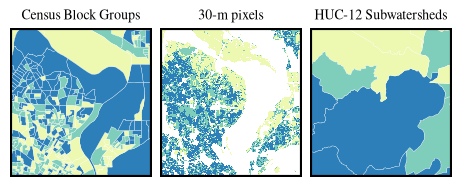

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.8), layout="constrained")

# Define your custom colors
custom_colors = ["#edf8b1", "#7fcdbb", "#2c7fb8"]
# Create a ListedColormap from your colors
my_cmap = ListedColormap(custom_colors)

cbg_sel.plot(
    ax=axs[0],
    column="total",
    edgecolor="white",
    scheme="Quantiles",
    k=3,
    lw=0.2,
    legend=False,
    cmap=my_cmap,
)
huc12_sel.plot(
    ax=axs[2],
    column=f"{study_period}_total",
    edgecolor="white",
    scheme="Quantiles",
    k=3,
    lw=0.2,
    legend=False,
    cmap=my_cmap,
)
plot_extent = plotting_extent(array, clipped_meta["transform"])
cmap, norm = from_levels_and_colors(
    [0, np.nanquantile(array, 0.33), np.nanquantile(array, 0.66), np.nanmax(array)],
    custom_colors,
)
axs[1].imshow(array, interpolation="none", cmap=cmap, norm=norm, extent=plot_extent)

# Set axis limits to match the bounds exactly
minx, miny, maxx, maxy = bbox_gdf.total_bounds
for ax in range(0,3):
    bbox_gdf.plot(ax=axs[ax], edgecolor="black", facecolor="None", lw=3)
    axs[ax].set_xlim(minx, maxx)
    axs[ax].set_ylim(miny, maxy)
    axs[ax].axis("off")


axs[0].set_title("Census Block Groups")
axs[1].set_title("30-m pixels")
axs[2].set_title("HUC-12 Subwatersheds")

plt.show()

fig.savefig(f"{root_dir}/figures/Figure S7.pdf")